# 06. M1 골격(skeleton) — 라벨링 불필요

사전학습 포즈 모델(**RTMPose**, rtmlib ONNX 런타임)을 클립에 그대로 돌려
관절 시계열을 뽑고, 여기서 **움직임 점수(D2)** 와 **손 올림/가시성(D4)** 을 계산합니다.
수동 라벨이 전혀 필요 없고, 결과는 `pose_results.csv` 로 Drive에 증분 저장됩니다.

마지막에 ① 기존 YDIF(픽셀 변화)와의 상관 비교, ② 골격 오버레이 영상으로
**아기 도메인에서 포즈가 실제로 잡히는지** 눈으로 검증합니다 — 여기서 성능이 나쁘면
SyRIP 파인튜닝(README [16])으로 넘어갑니다.

In [1]:
!pip -q install rtmlib onnxruntime-gpu decord opencv-python-headless pandas matplotlib av decord


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 220.3/220.3 MB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 115.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.5/35.5 MB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 99.4 MB/s eta 0:00:00


In [3]:
# 경로 설정 + Drive 마운트 (Colab)
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
BASE = Path('/content/drive/MyDrive/BabyMon/dataset')   # ← 업로드 위치에 맞게 수정
assert BASE.exists(), f'{BASE} 없음 — Drive 업로드 위치를 확인하세요'

# 클립 폴더 자동 탐색 (clips/ 또는 resized_2/ 또는 BASE 바로 아래)
CLIPS = None
for cand in (BASE/'clips', BASE/'resized_2', BASE):
    if cand.is_dir() and next(cand.glob('*.mp4'), None):
        CLIPS = cand; break
assert CLIPS, f'{BASE} 아래에서 mp4 폴더를 못 찾음 (clips/ 또는 resized_2/)'
assert (BASE/'manifest.csv').exists(), \
    f'{BASE}/manifest.csv 없음 — 로컬 D:\\carved\\dataset\\manifest.csv 와 labels.csv 를 이 폴더로 업로드하세요'
WORK = Path('/content/work'); WORK.mkdir(exist_ok=True)
print('clips:', CLIPS, '/', len(list(CLIPS.glob("*.mp4"))), '개')

Mounted at /content/drive
clips: /content/drive/MyDrive/BabyMon/dataset/clips / 24080 개


In [4]:
# 포즈 모델 초기화 (COCO-17 keypoints)
import torch, numpy as np, pandas as pd, decord, cv2, json
from rtmlib import Body
DEV = 'cuda' if torch.cuda.is_available() else 'cpu'
body = Body(mode='lightweight', backend='onnxruntime', device=DEV)

FPS_POSE = 5          # 포즈 추출 프레임레이트 (8초 → 40프레임)
KP_THR = 0.3          # keypoint 신뢰도 문턱
MOVE_THR = 0.03       # '움직인 창' 판정 (torso 대비 변위)
# COCO17: 0코 1-2눈 3-4귀 5-6어깨 7-8팔꿈치 9-10손목 11-12엉덩이

def pose_clip(path):
    """클립 → 관절 시계열 → 지표 dict"""
    vr = decord.VideoReader(str(path))
    n = len(vr)
    dur = max(n / max(vr.get_avg_fps(), 1), 0.5)
    ix = np.linspace(0, n-1, max(int(dur*FPS_POSE), 4)).astype(int)
    kps, scs = [], []
    for i in ix:
        fr = cv2.cvtColor(vr[i].asnumpy(), cv2.COLOR_RGB2BGR)
        k, s = body(fr)
        if len(k):                                   # 최고 신뢰 인물 1명
            b = np.argmax(s.mean(axis=1))
            kps.append(k[b]); scs.append(s[b])
        else:
            kps.append(np.full((17,2), np.nan)); scs.append(np.zeros(17))
    kps, scs = np.array(kps), np.array(scs)          # T,17,2 / T,17

    present = (scs.mean(axis=1) > KP_THR)            # 프레임별 인물 존재
    # torso 크기로 정규화한 프레임간 변위
    torso = np.nanmean([np.linalg.norm(kps[:,5]-kps[:,11], axis=1),
                        np.linalg.norm(kps[:,6]-kps[:,12], axis=1)], axis=0)
    torso = np.where(torso > 1, torso, np.nan)
    disp = np.linalg.norm(np.diff(kps, axis=0), axis=2)          # T-1,17
    vis = (scs[:-1] > KP_THR) & (scs[1:] > KP_THR)
    disp = np.where(vis, disp, np.nan)
    md = np.nanmean(disp, axis=1) / torso[:-1]                    # 프레임간 정규화 변위
    w = FPS_POSE                                                  # 1초 창
    curve = [float(np.nanmean(md[i:i+w])) for i in range(0, len(md), w)]
    curve = [c for c in curve if not np.isnan(c)]
    # 손: 손목 가시성 + 코 위(이미지 y 작음)로 올라옴
    wrist_vis = (scs[:, 9:11] > KP_THR)
    nose_y = np.where(scs[:,0] > KP_THR, kps[:,0,1], np.nan)
    up = ((kps[:,9,1] < nose_y) & wrist_vis[:,0]) | ((kps[:,10,1] < nose_y) & wrist_vis[:,1])
    return {
        'present_frac': round(float(present.mean()), 3),
        'move_mean': round(float(np.nanmean(md)), 4) if len(md) else None,
        'move_frac': round(float(np.mean([c > MOVE_THR for c in curve])), 3) if curve else None,
        'move_curve': json.dumps([round(c,4) for c in curve]),
        'wrist_vis_frac': round(float(wrist_vis.any(axis=1).mean()), 3),
        'hands_up_frac': round(float(np.nanmean(up.astype(float))), 3),
    }

Downloading: "https://download.openmmlab.com/mmpose/v1/projects/rtmposev1/onnx_sdk/yolox_tiny_8xb8-300e_humanart-6f3252f9.zip" to /root/.cache/rtmlib/hub/checkpoints/yolox_tiny_8xb8-300e_humanart-6f3252f9.zip
100%|██████████| 18.0M/18.0M [00:01<00:00, 18.3MB/s]
/usr/local/lib/python3.12/dist-packages/onnxruntime/capi/onnxruntime_inference_collection.py:153: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(
Downloading: "https://download.openmmlab.com/mmpose/v1/projects/rtmposev1/onnx_sdk/rtmpose-s_simcc-body7_pt-body7_420e-256x192-acd4a1ef_20230504.zip" to /root/.cache/rtmlib/hub/checkpoints/rtmpose-s_simcc-body7_pt-body7_420e-256x192-acd4a1ef_20230504.zip


load /root/.cache/rtmlib/hub/checkpoints/yolox_tiny_8xb8-300e_humanart-6f3252f9.onnx with onnxruntime backend


100%|██████████| 19.5M/19.5M [00:00<00:00, 25.4MB/s]


load /root/.cache/rtmlib/hub/checkpoints/rtmpose-s_simcc-body7_pt-body7_420e-256x192-acd4a1ef_20230504.onnx with onnxruntime backend


In [5]:
# 배치 실행 — 우선순위 표본부터, 증분 저장 (여러 세션 이어서 가능)
N_CLIPS = 2000        # 이번 세션에 처리할 개수 (전체는 세션 여러 번)
man = pd.read_csv(BASE/'manifest.csv')
res_path = BASE/'pose_results.csv'
done = set(pd.read_csv(res_path)['file']) if res_path.exists() else set()

# 표본: mean_ydif 스펙트럼 전체에서 고르게 (비교 실험용)
man['ydif'] = pd.to_numeric(man['mean_ydif'], errors='coerce')
todo = man[~man['file'].isin(done)].sort_values('ydif')
step = max(len(todo)//N_CLIPS, 1)
todo = todo.iloc[::step]['file'].tolist()[:N_CLIPS]
print(f'완료 {len(done)} / 이번 {len(todo)}')

import csv, time
cols = ['file','present_frac','move_mean','move_frac','move_curve','wrist_vis_frac','hands_up_frac']
new = not res_path.exists()
t0 = time.time()
with open(res_path, 'a', newline='') as f:
    w = csv.DictWriter(f, fieldnames=cols)
    if new: w.writeheader()
    for i, name in enumerate(todo):
        try:
            r = pose_clip(CLIPS/name)
        except Exception as e:
            print('skip', name, e); continue
        w.writerow({'file': name, **r}); f.flush()
        if (i+1) % 50 == 0:
            print(f'{i+1}/{len(todo)}  ({(time.time()-t0)/(i+1):.2f}s/clip)')
print('완료 →', res_path)

완료 0 / 이번 2000


/tmp/ipykernel_3405/177728764.py:37: RuntimeWarning: Mean of empty slice
  md = np.nanmean(disp, axis=1) / torso[:-1]                    # 프레임간 정규화 변위
/tmp/ipykernel_3405/177728764.py:39: RuntimeWarning: Mean of empty slice
  curve = [float(np.nanmean(md[i:i+w])) for i in range(0, len(md), w)]
/tmp/ipykernel_3405/177728764.py:47: RuntimeWarning: Mean of empty slice
  'move_mean': round(float(np.nanmean(md)), 4) if len(md) else None,


50/2000  (5.11s/clip)
100/2000  (4.92s/clip)
150/2000  (4.89s/clip)
200/2000  (4.82s/clip)
250/2000  (4.80s/clip)
300/2000  (4.82s/clip)
350/2000  (4.80s/clip)
400/2000  (4.79s/clip)
450/2000  (4.78s/clip)
500/2000  (4.78s/clip)
550/2000  (4.77s/clip)
600/2000  (4.75s/clip)
650/2000  (4.76s/clip)
700/2000  (4.77s/clip)
750/2000  (4.77s/clip)
800/2000  (4.77s/clip)
850/2000  (4.76s/clip)
900/2000  (4.76s/clip)
950/2000  (4.76s/clip)
1000/2000  (4.77s/clip)
1050/2000  (4.78s/clip)
1100/2000  (4.79s/clip)
1150/2000  (4.80s/clip)
1200/2000  (4.79s/clip)
1250/2000  (4.79s/clip)
1300/2000  (4.79s/clip)
1350/2000  (4.79s/clip)
1400/2000  (4.78s/clip)
1450/2000  (4.79s/clip)
1500/2000  (4.79s/clip)
1550/2000  (4.79s/clip)
1600/2000  (4.78s/clip)
1650/2000  (4.79s/clip)
1700/2000  (4.79s/clip)
1750/2000  (4.79s/clip)
1800/2000  (4.80s/clip)
1850/2000  (4.80s/clip)
1900/2000  (4.79s/clip)
1950/2000  (4.80s/clip)
2000/2000  (4.80s/clip)
완료 → /content/drive/MyDrive/BabyMon/dataset/pose_results.csv

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44264 (\N{HANGUL SYLLABLE GOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44201 (\N{HANGUL SYLLABLE GYEOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54589 (\N{HANGUL SYLLABLE PIG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49472 (\N{HANGUL SYLLABLE SEL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50880 (\N{HANGUL SYLLABLE UM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr

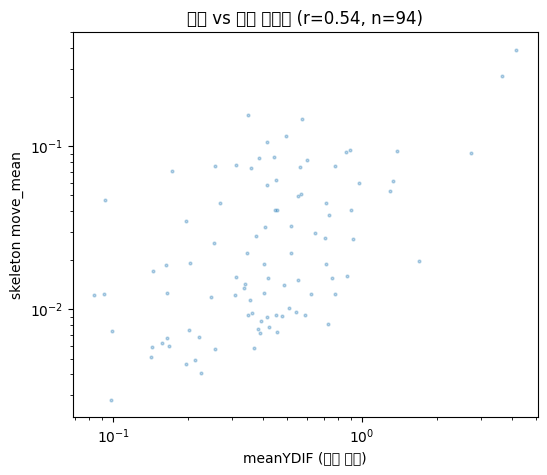

인물 검출 실패(present<0.5): 0.953 → 이 비율이 높으면 아기 도메인 갭 큼 → SyRIP 파인튜닝 필요


In [6]:
# 검증 1 — 골격 움직임 점수 vs 픽셀 YDIF 상관 (논문 실험거리)
import matplotlib.pyplot as plt
res = pd.read_csv(res_path).merge(man[['file','ydif']], on='file')
ok = res.dropna(subset=['move_mean','ydif'])
ok = ok[ok.present_frac > 0.5]                     # 인물이 잡힌 클립만
r = np.corrcoef(np.log10(ok.ydif+1e-3), np.log10(ok.move_mean+1e-4))[0,1]
plt.figure(figsize=(6,5))
plt.scatter(ok.ydif, ok.move_mean, s=4, alpha=.3)
plt.xscale('log'); plt.yscale('log')
plt.xlabel('meanYDIF (픽셀 변화)'); plt.ylabel('skeleton move_mean')
plt.title(f'골격 vs 픽셀 움직임 (r={r:.2f}, n={len(ok)})')
plt.show()
print('인물 검출 실패(present<0.5):', (res.present_frac <= 0.5).mean().round(3),
      '→ 이 비율이 높으면 아기 도메인 갭 큼 → SyRIP 파인튜닝 필요')

In [8]:
# 검증 2 — 골격 오버레이 눈검증 (움직임 많은 클립 3개)
from IPython.display import Video, display
EDGES = [(5,7),(7,9),(6,8),(8,10),(5,6),(5,11),(6,12),(11,12),(11,13),(13,15),(12,14),(14,16),(0,5),(0,6)]
for name in res.sort_values('move_mean', ascending=False)['file'].head(3):
    vr = decord.VideoReader(str(CLIPS/name))
    out = cv2.VideoWriter(str(WORK/f'ov_{name}'), cv2.VideoWriter_fourcc(*'mp4v'),
                          8, (vr[0].shape[1], vr[0].shape[0]))
    ix = np.linspace(0, len(vr)-1, 32).astype(int)
    for i in ix:
        fr = cv2.cvtColor(vr[i].asnumpy(), cv2.COLOR_RGB2BGR)
        k, s = body(fr)
        if len(k):
            b = np.argmax(s.mean(axis=1)); kp, sc = k[b], s[b]
            for a, c in EDGES:
                if sc[a] > KP_THR and sc[c] > KP_THR:
                    cv2.line(fr, tuple(kp[a].astype(int)), tuple(kp[c].astype(int)), (0,255,0), 1)
            for j in range(17):
                if sc[j] > KP_THR:
                    cv2.circle(fr, tuple(kp[j].astype(int)), 2, (0,0,255), -1)
        out.write(fr)
    out.release()
    print(name)
    display(Video(str(WORK/f'ov_{name}'), embed=True, width=480))

2026-07-19_00-21-56.mp4


2026-07-07_09-26-24.mp4


2026-06-30_21-38-57.mp4


### 해석·다음 단계
- **오버레이가 아기 몸에 제대로 붙으면** → 이 결과로 D2(move_frac)·D4(hands_up/wrist_vis) 판정 규칙을
  바로 만들 수 있음 (임계값은 분포 보고 조정). `pose_results.csv` 가 곧 모듈 출력.
- **관절이 엉뚱한 곳에 찍히면**(present_frac 낮음, 오버레이 엉망) → 성인 학습 모델의 아기 도메인 갭
  → SyRIP/FiDIP 파인튜닝 단계로 (README [16]). 그래도 이 노트북의 지표 코드는 그대로 재사용.
- rtmlib 대신 `mediapipe`(CPU 가볍고 설치 쉬움)로 바꿔 비교해도 좋음 — `pose_clip` 안의
  추론 두 줄만 교체하면 됨.